In [1]:
# base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.indexing import need_slice

# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (log_loss, average_precision_score,
                             precision_score, recall_score,
                             roc_auc_score, f1_score,
                             roc_curve, precision_recall_curve)

# Utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import optuna
import shap


import warnings
warnings.filterwarnings(
    'ignore',
    message='Found unknown categories.*',
    category=UserWarning
)

C:\Users\bekishev\Desktop\Credit Risk Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants
RANDOM_SEED = 42
PATH_TO_TRAIN_DATA = '../data/train-FIN_ANA_DATA.xls'
PATH_TO_TEST_DATA = '../data/test-FIN_ANA_DATA.xls'

In [3]:
df_train = pd.read_excel(PATH_TO_TRAIN_DATA)
df_test= pd.read_excel(PATH_TO_TEST_DATA)

In [4]:
# Target value encoding
mapping = {"G": 0, "B": 1}
df_train['QUALITY_OF_LOAN'] = df_train["QUALITY_OF_LOAN"].map(mapping)
df_test['QUALITY_OF_LOAN'] = df_test["QUALITY_OF_LOAN"].map(mapping)

In [5]:
X = df_train.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y = df_train['QUALITY_OF_LOAN']

X_test = df_test.drop(columns=['QUALITY_OF_LOAN', 'ACC_NO'])
y_test = df_test['QUALITY_OF_LOAN']

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=RANDOM_SEED)
X_val, X_cal, y_val, y_cal = train_test_split(X_temp, y_temp, test_size=0.33,
                                              stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train DataFrame length is {X_train.shape[0]} ({X_train.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Validation DataFrame length is {X_val.shape[0]} ({X_val.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Calibration Dataframe length is {X_cal.shape[0]} ({X_cal.shape[0] / df_train.shape[0] * 100:.1f}%)")
print(f"Test DataFrame length is {X_test.shape[0]}")

Train DataFrame length is 26185 (70.0%)
Validation DataFrame length is 7519 (20.1%)
Calibration Dataframe length is 3704 (9.9%)
Test DataFrame length is 4310


In [7]:
categorial_features = ['INF_MARITAL_STATUS', 'INF_GENDER',
                       'COMPENSATION_CHARGED', 'CLIENT_TYPE',
                       'REPAY_MODE']
numeric_features = ['INVESTMENT_TOTAL', 'ACCCURRENTBALANCE',
                    'INSTALL_SIZE', 'DUE_PAYMENT']

In [8]:
# LOGISTIC REGRESSION

# Numeric features preprocessing
numeric_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', RobustScaler())
])

# Categorial features preprocessing
categorial_pipeline_logreg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(
        drop='first',
        handle_unknown='infrequent_if_exist',
        min_frequency=0.01,
        sparse_output=False))
])

log_reg_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_logreg, numeric_features),
    ('categorical', categorial_pipeline_logreg, categorial_features)
])

# Logistic Regression Pipeline
logreg_pipe = Pipeline(steps=[
    ('log_reg_transformer', log_reg_transformer),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED))
])

In [9]:
# XGBOOST

# Numeric features preprocessing
numeric_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1))
])

# Categorial features preprocessing
categorial_pipeline_xgb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


xgb_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_xgb, numeric_features),
    ('categorical', categorial_pipeline_xgb, categorial_features)
])

# XGBoost Pipeline
xgb_pipeline = Pipeline(steps=[
    ('xgb_transformer', xgb_transformer),
    ('model', XGBClassifier(
        random_state=RANDOM_SEED))
])

In [10]:
# CATBOOST

# Numeric features preprocessing
numeric_pipeline_catboost = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1))
])

# Categorial features preprocessing
categorial_pipeline_catboost = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('zero_imputer', SimpleImputer(missing_values=0, strategy='constant', fill_value='missing'))
])

catboost_transformer = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline_catboost, numeric_features),
    ('categorical', categorial_pipeline_catboost, categorial_features)
])

cat_features_indices = list(
    range(
        len(numeric_features),
        len(numeric_features) + len(categorial_features)
    )
)

# Catboost Pipeline
catboost_pipeline = Pipeline(steps=[
    ('catboost_transformer', catboost_transformer),
    ('model', CatBoostClassifier(random_state=RANDOM_SEED,
                                 cat_features=cat_features_indices,
                                 verbose=False))
])

In [11]:
metrics_table = pd.DataFrame(
    columns=['Model', 'Precision', 'Recall',
             'F1', 'Logloss', 'PR-AUC', 'ROC-AUC']
)

# Logistic Regression
logreg_pipe.fit(X_train, y_train)
y_proba_logreg_val = logreg_pipe.predict_proba(X_val)[:, 1]
y_pred_logreg_val = (y_proba_logreg_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Logistic Regression (base)',
    round(precision_score(y_val, y_pred_logreg_val), 3),
    round(recall_score(y_val, y_pred_logreg_val), 3),
    round(f1_score(y_val, y_pred_logreg_val), 3),
    round(log_loss(y_val, y_proba_logreg_val), 3),
    round(average_precision_score(y_val, y_proba_logreg_val), 3),
    round(roc_auc_score(y_val, y_proba_logreg_val), 3)
]

# XGBoost
xgb_pipeline.fit(X_train, y_train)
y_proba_xgb_val = xgb_pipeline.predict_proba(X_val)[:, 1]
y_pred_xgb_val = (y_proba_xgb_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'XGBoost (base)',
    round(precision_score(y_val, y_pred_xgb_val), 3),
    round(recall_score(y_val, y_pred_xgb_val), 3),
    round(f1_score(y_val, y_pred_xgb_val), 3),
    round(log_loss(y_val, y_proba_xgb_val), 3),
    round(average_precision_score(y_val, y_proba_xgb_val), 3),
    round(roc_auc_score(y_val, y_proba_xgb_val), 3)
]

# Catboost
catboost_pipeline.fit(X_train, y_train)
y_proba_catboost_val = catboost_pipeline.predict_proba(X_val)[:, 1]
y_pred_catboost_val = (y_proba_catboost_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'Catboost (base)',
    round(precision_score(y_val, y_pred_catboost_val), 3),
    round(recall_score(y_val, y_pred_catboost_val), 3),
    round(f1_score(y_val, y_pred_catboost_val), 3),
    round(log_loss(y_val, y_proba_catboost_val), 3),
    round(average_precision_score(y_val, y_proba_catboost_val), 3),
    round(roc_auc_score(y_val, y_proba_catboost_val), 3)
]

metrics_table

,Model,Precision,Recall,F1,Logloss,PR-AUC,ROC-AUC
0,Logistic Regression (base),0.165,0.662,0.264,0.659,0.187,0.663
1,XGBoost (base),0.729,0.174,0.280,0.280,0.437,0.793
2,Catboost (base),0.844,0.097,0.174,0.288,0.414,0.781


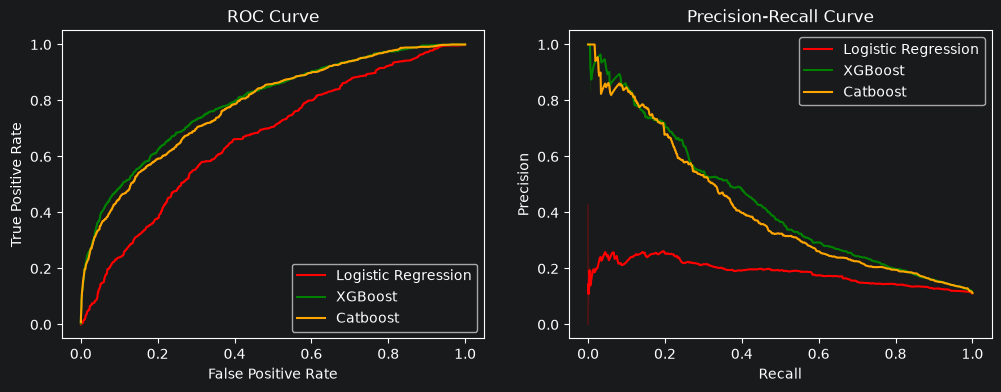

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(ax1, ax2) = axes.flatten()

# ROC Curve
fpr_logreg, tpr_logreg, _ = roc_curve(y_val, y_proba_logreg_val)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_proba_xgb_val)
fpr_catboost, tpr_catboost, _ = roc_curve(y_val, y_proba_catboost_val)

sns.lineplot(x=fpr_logreg, y=tpr_logreg, ax=ax1, color='red', label='Logistic Regression')
sns.lineplot(x=fpr_xgb, y=tpr_xgb, ax=ax1, color='green', label='XGBoost')
sns.lineplot(x=fpr_catboost, y=tpr_catboost, ax=ax1, color='orange', label='Catboost')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')


# PR Curve
precision_logreg, recall_logreg, _ = precision_recall_curve(
    y_val, y_proba_logreg_val
)
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_val, y_proba_xgb_val
)
precision_catboost, recall_catboost, _ = precision_recall_curve(
    y_val, y_proba_catboost_val
)

sns.lineplot(x=recall_logreg, y=precision_logreg, ax=ax2, color='red', label='Logistic Regression')
sns.lineplot(x=recall_xgb, y=precision_xgb, ax=ax2, color='green', label='XGBoost')
sns.lineplot(x=recall_catboost, y=precision_catboost, ax=ax2, color='orange', label='Catboost')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='upper right')

plt.show()

## Hyperparameter tuning

In [13]:
# LOGISTIC REGRESSION

param_grid = [
    {
        'model__solver': ['liblinear'],
        'model__l1_ratio': [0, 1],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model__solver': ['lbfgs'],
        'model__l1_ratio': [0],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model__solver': ['saga'],
        'model__l1_ratio': [0, 0.25, 0.5, 0.75, 1],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': [None, 'balanced']
    }
]

grid_search = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5,
                       shuffle=True,
                       random_state=RANDOM_SEED),
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'model__C': 100, 'model__class_weight': None, 'model__l1_ratio': 1, 'model__solver': 'liblinear'}
0.20198047870492447


### TODO: Fit and add to result_table

In [13]:
# XGBOOST
def objective_xgb(trial_xgb):

    params = {
        'model__n_estimators': trial_xgb.suggest_int(
            'n_estimators', 100, 800
        ),
        'model__max_depth': trial_xgb.suggest_int(
            'max_depth', 3, 10
        ),
        'model__learning_rate': trial_xgb.suggest_float(
            'learning_rate', 0.01, 0.3, log=True
        ),
        'model__subsample': trial_xgb.suggest_float(
            'subsample', 0.6, 1.0
        ),
        'model__colsample_bytree': trial_xgb.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),
        'model__min_child_weight': trial_xgb.suggest_int(
            'min_child_weight', 1, 20
        ),
        'model__gamma': trial_xgb.suggest_float(
            'gamma', 0.0, 5.0
        ),
        'model__reg_alpha': trial_xgb.suggest_float(
            'reg_alpha', 1e-8, 10.0, log=True
        ),
        'model__reg_lambda': trial_xgb.suggest_float(
            'reg_lambda', 1e-8, 10.0, log=True
        )
    }

    pipeline = Pipeline(steps=[
        ('xgb_transformer', xgb_transformer),
        ('model', XGBClassifier(eval_metric='logloss',
                                random_state=RANDOM_SEED))
    ])
    pipeline.set_params(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1
    )

    return scores.mean()

study_xgb = optuna.create_study(direction='maximize')

study_xgb.optimize(
    objective_xgb,
    n_trials=50
)

[I 2026-08-06 16:25:36,454] A new study created in memory with name: no-name-dd98339b-5e2e-4788-82fd-af1eb710bf77
[I 2026-08-06 16:25:43,790] Trial 0 finished with value: 0.31937674145164396 and parameters: {'n_estimators': 148, 'max_depth': 7, 'learning_rate': 0.04806772819217592, 'subsample': 0.8425640968177439, 'colsample_bytree': 0.817362769971455, 'min_child_weight': 18, 'gamma': 0.7002203714000427, 'reg_alpha': 0.00048617075445364476, 'reg_lambda': 0.8743260290439729}. Best is trial 0 with value: 0.31937674145164396.
[I 2026-08-06 16:25:45,761] Trial 1 finished with value: 0.2654751788616475 and parameters: {'n_estimators': 125, 'max_depth': 6, 'learning_rate': 0.013801369555524527, 'subsample': 0.8278169486604711, 'colsample_bytree': 0.7706006035740964, 'min_child_weight': 7, 'gamma': 0.4685843258847472, 'reg_alpha': 2.3707713668204646, 'reg_lambda': 0.00020337621252642553}. Best is trial 0 with value: 0.31937674145164396.
[I 2026-08-06 16:25:51,786] Trial 2 finished with value:

In [18]:
best_xgb = Pipeline(steps=[
    ('xgb_transformer', xgb_transformer),
    ('model', XGBClassifier(
        **study_xgb.best_params,
        random_state=RANDOM_SEED
    ))
])

best_xgb.fit(X_train, y_train)
y_proba_xgb_val = best_xgb.predict_proba(X_val)[:, 1]
y_pred_xgb_val = (y_proba_xgb_val >= 0.5).astype(int)
metrics_table.loc[len(metrics_table)] = [
    'XGBoost (optimized)',
    round(precision_score(y_val, y_pred_xgb_val), 3),
    round(recall_score(y_val, y_pred_xgb_val), 3),
    round(f1_score(y_val, y_pred_xgb_val), 3),
    round(log_loss(y_val, y_proba_xgb_val), 3),
    round(average_precision_score(y_val, y_proba_xgb_val), 3),
    round(roc_auc_score(y_val, y_proba_xgb_val), 3)
]

In [19]:
metrics_table

,Model,Precision,Recall,F1,Logloss,PR-AUC,ROC-AUC
0,Logistic Regression (base),0.165,0.662,0.264,0.659,0.187,0.663
1,XGBoost (base),0.729,0.174,0.280,0.280,0.437,0.793
2,Catboost (base),0.844,0.097,0.174,0.288,0.414,0.781
3,XGBoost (optimized),0.770,0.184,0.298,0.271,0.476,0.810
